# Predict mechanism from experimental points

Point `DATA_PATH` at **your own CSV**. `experiments/example.csv` is only a column template.

Required columns: `Step`, `Time`, `Cat0`, `[S]`, `[P]`.
`Cat0` is a mole fraction; `[S]` and `[P]` are unitless concentrations on the `S0 = 1` scale.
Initial conditions default to `S0 = 1`, `P0 = 0`.

Set `CKPT_PATHS` to one or more checkpoints (single model or any ensemble subset).
Set `MODE` to `overall` (all rows as one set) or `stepwise` (predict after `Step` 1, 2, …).


In [11]:
from pathlib import Path

ROOT = Path.cwd()
for p in [ROOT, *ROOT.parents]:
    if (p / "src").is_dir() and (p / "checkpoints").is_dir():
        ROOT = p
        break

# Replace with your CSV (same columns as example.csv).
DATA_PATH = ROOT / "experiments" / "example.csv"

# One file = single model. Several files = ensemble (mean of softmax).
CKPT_PATHS = [ROOT / "checkpoints" / f"combined_member_{i}.pth" for i in range(5)]
# CKPT_PATHS = [ROOT / "checkpoints" / "default_member_0.pth"]
# CKPT_PATHS = [ROOT / "checkpoints" / f"default_member_{i}.pth" for i in range(5)]

MODE = "stepwise"  # "overall" or "stepwise"
S0, P0 = 1.0, 0.0
GPU = None  # e.g. 0, or None for auto


In [12]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.patches import Patch
from scipy.stats import entropy as scipy_entropy

if GPU is not None:
    os.environ.setdefault("CUDA_DEVICE_ORDER", "PCI_BUS_ID")
    os.environ["CUDA_VISIBLE_DEVICES"] = str(GPU)

sys.path.insert(0, str(ROOT / "src"))
os.chdir(ROOT)

from eval import load_model
from utils.scattered_dataset import ScatteredKineticDataset, time_values_minutes

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("checkpoints:")
for p in CKPT_PATHS:
    print(" ", Path(p).name)


device: cuda
checkpoints:
  combined_member_0.pth
  combined_member_1.pth
  combined_member_2.pth
  combined_member_3.pth
  combined_member_4.pth


In [13]:
def load_experiment_csv(path, s0=1.0, p0=0.0):
    raw = pd.read_csv(path)
    df = pd.DataFrame(
        {
            "step": raw["Step"].astype(int),
            "t": time_values_minutes(raw),
            "cat0": raw["Cat0"].astype(float),
            "St": raw["[S]"].astype(float),
            "Pt": raw["[P]"].astype(float),
            "S0": s0,
            "P0": p0,
        }
    )
    return df.sort_values("step").reset_index(drop=True)


def features_from_df(df):
    ds = ScatteredKineticDataset(df[["t", "cat0", "S0", "P0", "St", "Pt"]], use_tau=False, noise_std=0.0)
    feat, _ = ds[0]
    return feat


def load_models(paths, device):
    models = []
    for p in paths:
        model, params, _ckpt = load_model(str(p), device)
        models.append(model)
        print(Path(p).name, params)
    return models


@torch.no_grad()
def predict_probs(models, feat, device):
    x = feat.unsqueeze(0).to(device)
    member = []
    for model in models:
        logits = model(x)
        member.append(torch.softmax(logits, dim=1).cpu().numpy()[0])
    member = np.stack(member, axis=0)
    return member.mean(axis=0), member


def topk_str(probs, k=5):
    idx = np.argsort(probs)[::-1][:k]
    return ", ".join(f"M{i+1} {probs[i]:.1%}" for i in idx)


def pred_entropy(probs):
    return float(scipy_entropy(np.clip(probs, 1e-12, 1.0)))


df = load_experiment_csv(DATA_PATH, S0, P0)
print(df.to_string(index=False, float_format="%.4f"))
feat_all = features_from_df(df)
models = load_models(CKPT_PATHS, device)


 step        t   cat0     St     Pt     S0     P0
    1  40.0000 0.0030 0.4097 0.5851 1.0000 0.0000
    2 120.0000 0.0040 0.2916 0.6787 1.0000 0.0000
    3 150.0000 0.0030 0.3266 0.6696 1.0000 0.0000
    4  20.0000 0.0010 0.6769 0.3212 1.0000 0.0000
    5 200.0000 0.0010 0.4729 0.5222 1.0000 0.0000
    6  70.0000 0.0100 0.1587 0.8039 1.0000 0.0000
    7  50.0000 0.0050 0.3131 0.6636 1.0000 0.0000
    8  20.0000 0.0100 0.2432 0.7228 1.0000 0.0000
    9  60.0000 0.0020 0.4088 0.5603 1.0000 0.0000
   10 100.0000 0.0020 0.4005 0.5653 1.0000 0.0000
combined_member_0.pth {'in_dim': 20, 'num_classes': 20, 'dim_hidden': 256, 'num_heads': 8, 'num_layers': 6, 'num_inducing': 16, 'num_pma_seeds': 1, 'dropout': 0.0}
combined_member_1.pth {'in_dim': 20, 'num_classes': 20, 'dim_hidden': 256, 'num_heads': 8, 'num_layers': 6, 'num_inducing': 16, 'num_pma_seeds': 1, 'dropout': 0.0}
combined_member_2.pth {'in_dim': 20, 'num_classes': 20, 'dim_hidden': 256, 'num_heads': 8, 'num_layers': 6, 'num_inducing'

In [14]:
if MODE == "overall":
    ens_probs, member_probs = predict_probs(models, feat_all, device)
    step_probs = ens_probs[None, :]
    print("overall  n_points =", len(df))
    print("ensemble ", topk_str(ens_probs), f"  H={pred_entropy(ens_probs):.4f}")
    if len(models) > 1:
        for m, p in enumerate(member_probs):
            print(f"member {m} ", topk_str(p), f"  H={pred_entropy(p):.4f}")
else:
    rows = []
    member_by_step = []
    for n in range(1, len(df) + 1):
        ens_probs, member_probs = predict_probs(models, feat_all[:n], device)
        rows.append(ens_probs)
        member_by_step.append(member_probs)
        pred = int(np.argmax(ens_probs))
        h = pred_entropy(ens_probs)
        print(f"n={n:<2}  pred=M{pred+1:<2}  p={ens_probs[pred]:.1%}  H={h:.4f}  {topk_str(ens_probs, 3)}")
    step_probs = np.stack(rows, axis=0)
    ens_probs = step_probs[-1]
    member_probs = member_by_step[-1]

step_entropy = np.array([pred_entropy(p) for p in step_probs])
pred_idx = int(np.argmax(ens_probs))
print(f"\nprediction: M{pred_idx + 1}  ({ens_probs[pred_idx]:.2%})  entropy={step_entropy[-1]:.4f}")


n=1   pred=M8   p=60.0%  H=1.4136  M8 60.0%, M12 13.0%, M17 11.2%
n=2   pred=M17  p=96.3%  H=0.2088  M17 96.3%, M16 1.8%, M12 1.0%
n=3   pred=M17  p=68.1%  H=0.9646  M17 68.1%, M12 17.1%, M14 8.1%
n=4   pred=M17  p=84.4%  H=0.6217  M17 84.4%, M14 7.1%, M12 3.9%
n=5   pred=M14  p=27.0%  H=1.3907  M14 27.0%, M12 26.3%, M17 23.7%
n=6   pred=M17  p=100.0%  H=0.0000  M17 100.0%, M12 0.0%, M14 0.0%
n=7   pred=M17  p=100.0%  H=0.0000  M17 100.0%, M15 0.0%, M12 0.0%
n=8   pred=M17  p=95.8%  H=0.1749  M17 95.8%, M15 4.2%, M10 0.0%
n=9   pred=M17  p=80.5%  H=0.4955  M17 80.5%, M15 19.5%, M10 0.0%
n=10  pred=M17  p=97.1%  H=0.1315  M17 97.1%, M15 2.9%, M10 0.0%

prediction: M17  (97.11%)  entropy=0.1315


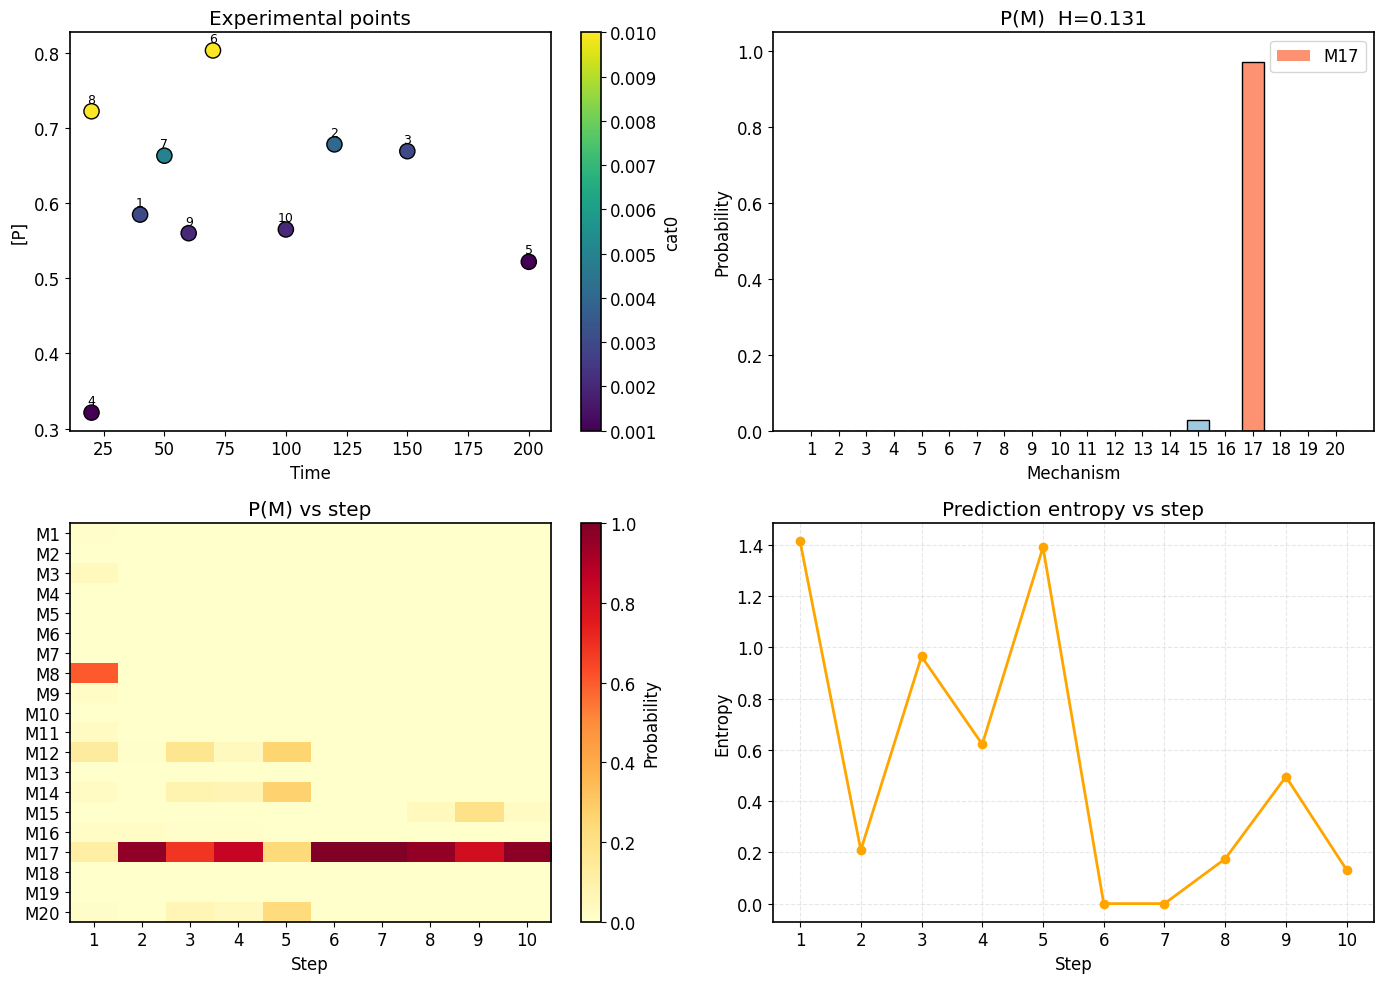

 n_points pred  p_top1  entropy    M1    M2    M3    M4    M5    M6    M7    M8    M9   M10   M11   M12   M13   M14   M15   M16   M17   M18   M19   M20
        1   M8   0.600    1.414 0.006 0.000 0.040 0.000 0.000 0.000 0.000 0.600 0.017 0.000 0.031 0.130 0.002 0.031 0.000 0.016 0.112 0.000 0.001 0.014
        2  M17   0.963    0.209 0.000 0.000 0.000 0.000 0.000 0.000 0.003 0.000 0.000 0.000 0.000 0.010 0.000 0.003 0.000 0.018 0.963 0.001 0.000 0.001
        3  M17   0.681    0.965 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.171 0.000 0.081 0.000 0.004 0.681 0.000 0.000 0.063
        4  M17   0.844    0.622 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.039 0.000 0.071 0.000 0.009 0.844 0.000 0.000 0.038
        5  M14   0.270    1.391 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.263 0.000 0.270 0.000 0.001 0.237 0.000 0.000 0.229
        6  M17   1.000    0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.

In [15]:
plt.rcParams.update({"font.size": 12, "axes.linewidth": 1.2})

if MODE == "overall":
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
else:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    ax1, ax2 = axes[0]
    ax3, ax4 = axes[1]

sc = ax1.scatter(df["t"], df["Pt"], c=df["cat0"], cmap="viridis", s=120, edgecolors="black", zorder=10)
for _, row in df.iterrows():
    ax1.annotate(str(int(row["step"])), (row["t"], row["Pt"]), textcoords="offset points", xytext=(0, 6), ha="center", fontsize=9)
ax1.set_xlabel("Time (min)")
ax1.set_ylabel("[P]")
ax1.set_title("Experimental points")
fig.colorbar(sc, ax=ax1, label="cat0")

bar_cols = ["#9ecae1"] * 20
bar_cols[pred_idx] = "#fc9272"
ax2.bar(range(1, 21), ens_probs, color=bar_cols, edgecolor="black")
ax2.set_xticks(range(1, 21))
ax2.set_ylim(0, 1.05)
ax2.set_xlabel("Mechanism")
ax2.set_ylabel("Probability")
ax2.set_title(f"P(M)  H={step_entropy[-1]:.3f}")
ax2.legend(handles=[Patch(facecolor="#fc9272", label=f"M{pred_idx + 1}")], loc="upper right")

if MODE == "stepwise":
    im = ax3.imshow(step_probs.T, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1, origin="upper")
    ax3.set_yticks(range(20))
    ax3.set_yticklabels([f"M{i+1}" for i in range(20)])
    ax3.set_xticks(range(len(df)))
    ax3.set_xticklabels([str(s) for s in df["step"]])
    ax3.set_xlabel("Step")
    ax3.set_title("P(M) vs step")
    fig.colorbar(im, ax=ax3, label="Probability")

    ax4.plot(df["step"], step_entropy, "o-", color="orange", lw=2)
    ax4.set_xlabel("Step")
    ax4.set_ylabel("Entropy")
    ax4.set_title("Prediction entropy vs step")
    ax4.set_xticks(df["step"])
    ax4.grid(True, ls="--", alpha=0.3)

fig.tight_layout()
plt.show()

if MODE == "stepwise":
    hist = pd.DataFrame(step_probs, columns=[f"M{i+1}" for i in range(20)])
    hist.insert(0, "n_points", range(1, len(df) + 1))
    hist.insert(1, "pred", [f"M{int(np.argmax(p))+1}" for p in step_probs])
    hist.insert(2, "p_top1", [float(np.max(p)) for p in step_probs])
    hist.insert(3, "entropy", step_entropy)
    print(hist.to_string(index=False, float_format="%.3f"))
elif MODE == "overall":
    print(f"entropy = {step_entropy[-1]:.4f}")
